# Introduction to Neural Networks

**Assignment**: 2

**Group 3**: Object Detection with YOLOv5 on Pascal VOC 2012

March 2026

## 1. Setup

In [1]:
import os
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor

## 2. Dataset

### 2.1 Dataset Class

In [2]:

class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.images[idx].replace(".jpg", ".txt"))

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load annotations
        boxes = []
        with open(label_path, "r") as f:
            for line in f.readlines():
                class_label, x, y, w, h = map(float, line.strip().split())
                boxes.append([class_label, x, y, w, h])

        if self.transforms:
            image = self.transforms(image)
        return image, torch.tensor(boxes)

### 2.2 DataLoader

A custom `collate_fn` is needed because images in the same batch can have different numbers of bounding boxes. The default PyTorch collate tries to stack all targets into a single tensor, which fails when their lengths differ, our function keeps targets as a list instead.

In [3]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images, 0), list(targets)

train_dataset = YOLODataset(
    img_dir="Pascal VOC 2012.v1/train/images",
    label_dir="Pascal VOC 2012.v1/train/labels",
    transforms=ToTensor()
)
val_dataset = YOLODataset(
    img_dir="Pascal VOC 2012.v1/valid/images",
    label_dir="Pascal VOC 2012.v1/valid/labels",
    transforms=ToTensor()
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples  : 13690
Validation samples: 3422


### 2.3 Sample Visualisation

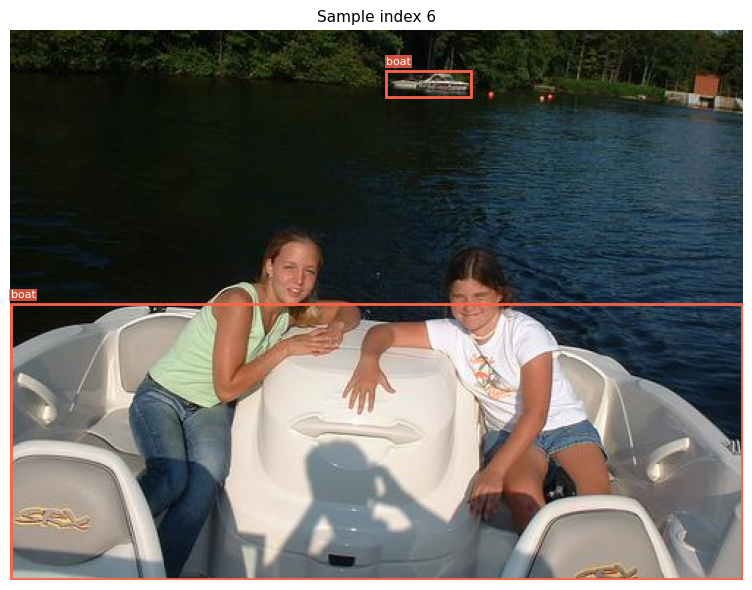

In [4]:
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def show_image_with_boxes(dataset, idx):
    image, boxes = dataset[idx]
    img = image.permute(1, 2, 0).numpy()
    img_h, img_w = img.shape[:2]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)

    for box in boxes:
        cls, cx, cy, w, h = box.tolist()
        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        rect = plt.Rectangle((x1, y1), w * img_w, h * img_h,
                              linewidth=2, edgecolor='tomato', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, VOC_CLASSES[int(cls)],
                fontsize=8, color='white',
                bbox=dict(facecolor='tomato', alpha=0.8, pad=1, edgecolor='none'))

    ax.axis('off')
    ax.set_title(f"Sample index {idx}", fontsize=11)
    plt.tight_layout()
    plt.show()

show_image_with_boxes(train_dataset, 6)

### 2.4 Class Distribution

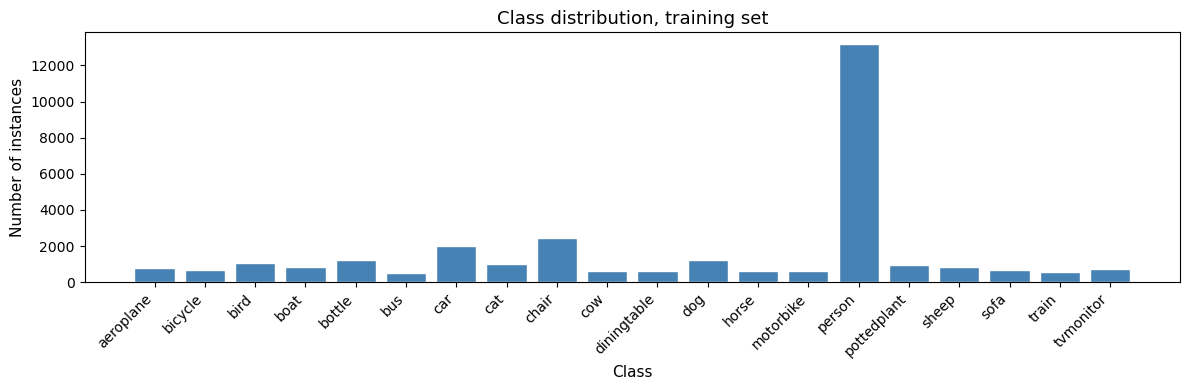

In [5]:
from collections import Counter

class_counts = Counter()
for _, boxes in train_dataset:
    for box in boxes:
        class_counts[int(box[0].item())] += 1

labels = [VOC_CLASSES[i] for i in range(20)]
counts = [class_counts.get(i, 0) for i in range(20)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(labels, counts, color='steelblue', edgecolor='white')
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Number of instances", fontsize=11)
ax.set_title("Class distribution, training set", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Model Architecture

YOLO frames object detection as a single regression problem: one forward pass predicts all boxes and class probabilities at once. The network has three parts, a **backbone** that reads the image and extracts features, a **detection head** that turns those features into box predictions, and a **loss function** that guides training. We build each from scratch.

### 3.1 ConvBlock

Every layer in the network is built on the same unit: a 2D convolution, batch normalisation to keep activations stable, and a Leaky ReLU. YOLO uses Leaky ReLU instead of regular ReLU because it allows a small gradient for negative inputs rather than zeroing them out entirely, which helps with vanishing gradients in deep nets.

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

### 3.2 Backbone

The backbone extracts features by repeatedly halving the spatial resolution while doubling the channel depth. The 1×1 convolutions between 3×3 blocks act as bottlenecks, they reduce the channel count before the expensive 3×3 operation, keeping the parameter count manageable.

In [7]:
class YOLOBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            ConvBlock(3,   32,  3, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(32,  64,  3, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(64,  128, 3, padding=1),
            ConvBlock(128, 64,  1),
            ConvBlock(64,  128, 3, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(128, 256, 3, padding=1),
            ConvBlock(256, 128, 1),
            ConvBlock(128, 256, 3, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(256, 512, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)

### 3.3 Detection Head

The head sits on top of the backbone and produces the final predictions. A 1×1 convolution maps each spatial position to `B × (5 + C)` values, five numbers per anchor (centre x, centre y, width, height, objectness) plus one score per class.

In [8]:
class YOLOHead(nn.Module):
    def __init__(self, num_classes=20, num_anchors=3):
        super().__init__()
        self.net = nn.Sequential(
            ConvBlock(512, 256, 1),
            ConvBlock(256, 512, 3, padding=1),
            nn.Conv2d(512, num_anchors * (5 + num_classes), 1),
        )

    def forward(self, x):
        return self.net(x).permute(0, 2, 3, 1).contiguous()

### 3.4 Full Model

`YOLODetector` wires the backbone and head together into one module.

In [9]:
class YOLODetector(nn.Module):
    def __init__(self, num_classes=20, num_anchors=3):
        super().__init__()
        self.backbone = YOLOBackbone()
        self.head     = YOLOHead(num_classes, num_anchors)

    def forward(self, x):
        return self.head(self.backbone(x))

### 3.5 Architecture Summary

A quick sanity check: instantiate the model, count the parameters, and confirm the output tensor has the expected shape.

In [10]:
_m = YOLODetector()
total  = sum(p.numel() for p in _m.parameters())
bb     = sum(p.numel() for p in _m.backbone.parameters())
head_p = sum(p.numel() for p in _m.head.parameters())

print(f"{'Component':<20} {'Parameters':>12}")
print('-' * 33)
print(f"{'Backbone':<20} {bb:>12,}")
print(f"{'Detection head':<20} {head_p:>12,}")
print(f"{'Total':<20} {total:>12,}")

x   = torch.zeros(1, 3, 320, 320)
out = _m(x)
print(f"\nInput  : {tuple(x.shape)}")
print(f"Output : {tuple(out.shape)}  ->  (batch, S, S, B *(5+C))")
del _m

Component              Parameters
---------------------------------
Backbone                1,980,320
Detection head          1,350,731
Total                   3,331,051

Input  : (1, 3, 320, 320)
Output : (1, 20, 20, 75)  ->  (batch, S, S, B *(5+C))


## 4. Loss Function

YOLO is trained by minimising a sum of five separate penalties. Getting them wrong in different ways costs different amounts, a missed detection costs more than a false background, and a small box with a big position error should cost as much as a large box with the same relative error.

### 4.1 Intersection over Union (IoU)

IoU measures how well two predicted boxes overlap with the ground truth. A score of 1 means a perfect match; 0 means no overlap at all. We use it later during evaluation to judge whether a detection counts as correct.

In [11]:
def iou(box1, box2):
    """
    box1, box2: [cx, cy, w, h] normalised to [0, 1]
    Returns scalar IoU value.
    """
    b1x1, b1y1 = box1[0] - box1[2] / 2, box1[1] - box1[3] / 2
    b1x2, b1y2 = box1[0] + box1[2] / 2, box1[1] + box1[3] / 2
    b2x1, b2y1 = box2[0] - box2[2] / 2, box2[1] - box2[3] / 2
    b2x2, b2y2 = box2[0] + box2[2] / 2, box2[1] + box2[3] / 2

    inter = max(0, min(b1x2, b2x2) - max(b1x1, b2x1)) * \
            max(0, min(b1y2, b2y2) - max(b1y1, b2y1))
    union = box1[2] * box1[3] + box2[2] * box2[3] - inter
    return inter / (union + 1e-6)

### 4.2 YOLO Loss

The loss has five terms:

- **Box centre loss** — penalises (cx, cy) predictions that are off, weighted by λ_coord = 5
- **Box size loss** — penalises wrong width and height. We compare *square roots* of the dimensions rather than raw values, so errors on small boxes cost as much as errors on large ones — this is one of the key ideas in the original YOLO paper
- **Object confidence loss** — penalises cells that contain an object but predict low confidence
- **No-object confidence loss** — penalises empty cells that fire, down-weighted by λ_noobj = 0.05. With a 20×20 grid and 3 anchors, roughly 1,180 out of 1,200 cells per image are empty — a much larger λ_noobj swamps the object signal and pushes all confidence scores to zero
- **Classification loss** — penalises wrong class predictions, but only in cells that do contain an object

In [12]:
def yolo_loss(predictions, targets, B=3, C=20, lambda_coord=5.0, lambda_noobj=0.05):
    batch_size = predictions.shape[0]
    total = 0

    for b in range(B):
        offset = b * (5 + C)

        pred_xy   = torch.sigmoid(predictions[..., offset:offset+2])
        pred_wh   = predictions[..., offset+2:offset+4]
        pred_conf = torch.sigmoid(predictions[..., offset+4])
        pred_cls  = predictions[..., offset+5:offset+5+C]

        tgt_xy   = targets[..., offset:offset+2]
        tgt_wh   = targets[..., offset+2:offset+4]
        tgt_conf = targets[..., offset+4]
        tgt_cls  = targets[..., offset+5:offset+5+C]

        obj = tgt_conf  # 1 where an object centre falls in this cell

        xy_loss    = lambda_coord * (obj.unsqueeze(-1) * (pred_xy - tgt_xy).pow(2)).sum()
        wh_loss    = lambda_coord * (obj.unsqueeze(-1) * (pred_wh.clamp(min=0).sqrt() - tgt_wh.clamp(min=0).sqrt()).pow(2)).sum()
        obj_loss   = (obj * (pred_conf - tgt_conf).pow(2)).sum()
        noobj_loss = lambda_noobj * ((1 - obj) * pred_conf.pow(2)).sum()
        cls_loss   = (obj.unsqueeze(-1) * (pred_cls - tgt_cls).pow(2)).sum()

        total = total + xy_loss + wh_loss + obj_loss + noobj_loss + cls_loss

    return total / batch_size

## 5. Training

### 5.1 Target Encoding

Before computing the loss, each ground-truth box needs to be placed into the right cell of the S×S grid. The function below builds the target tensor in the shape the loss expects, `[S, S, B×(5+C)]`, where only the cells whose centre falls within a ground-truth box have non-zero values.

In [13]:
S = 20
B = 3
C = 20

def encode_targets(boxes, S=S, B=B, C=C):
    """
    boxes : [num_boxes, 5]  each row is [class, cx, cy, w, h]  (normalised 0-1)
    returns: [S, S, B*(5+C)] tensor
    """
    target = torch.zeros(S, S, B * (5 + C))
    for box in boxes:
        cls, cx, cy, w, h = box.tolist()
        i = min(int(cx * S), S - 1)
        j = min(int(cy * S), S - 1)
        for b in range(B):
            offset = b * (5 + C)
            target[j, i, offset:offset+4]     = torch.tensor([cx, cy, w, h])
            target[j, i, offset+4]            = 1.0
            target[j, i, offset+5+int(cls)]   = 1.0
    return target

### 5.2 Hyperparameters and Data

We resize all images to 320×320, large enough to preserve most spatial detail while keeping memory use reasonable on CPU. A subset of 500 images keeps the demo run time short without hiding whether the model can learn at all.

In [14]:
HPARAMS = {
    'imgsz': 320,
    'batch': 8,
    'epochs': 10,
    'lr': 1e-3,
    'subset_size': 500,
}

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((HPARAMS['imgsz'], HPARAMS['imgsz'])),
    T.ToTensor(),
])

full_train = YOLODataset(
    img_dir='Pascal VOC 2012.v1/train/images',
    label_dir='Pascal VOC 2012.v1/train/labels',
    transforms=transform,
)
full_train.images = random.sample(full_train.images, HPARAMS['subset_size'])

train_loader = DataLoader(
    full_train,
    batch_size=HPARAMS['batch'],
    shuffle=True,
    collate_fn=collate_fn,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on : {device}")
print(f"Samples     : {len(full_train)},  batches/epoch: {len(train_loader)}")

Training on : cpu
Samples     : 500,  batches/epoch: 63


### 5.3 Training Loop

Adam optimiser with an initial learning rate of 0.001. After each epoch we record the average loss so we can plot the learning curve later.

In [15]:
model = YOLODetector(num_classes=C, num_anchors=B).to(device)
optimizer = optim.Adam(model.parameters(), lr=HPARAMS['lr'])

history = []

for epoch in range(HPARAMS['epochs']):
    model.train()
    epoch_loss = 0.0

    for images, targets in train_loader:
        images  = images.to(device)
        encoded = torch.stack([encode_targets(t) for t in targets]).to(device)

        preds = model(images)
        loss  = yolo_loss(preds, encoded, B=B, C=C)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    history.append(avg)
    print(f"Epoch {epoch+1:>2}/{HPARAMS['epochs']}  loss: {avg:.4f}")

torch.save(model.state_dict(), 'yolo_voc.pt')
print("\nModel saved to yolo_voc.pt")

Epoch  1/10  loss: 26.9997
Epoch  2/10  loss: 19.0170
Epoch  3/10  loss: 18.8759
Epoch  4/10  loss: 19.5993
Epoch  5/10  loss: 21.5360
Epoch  6/10  loss: 19.6405
Epoch  7/10  loss: 17.2296
Epoch  8/10  loss: 23.8580
Epoch  9/10  loss: 20.6632
Epoch 10/10  loss: 17.1088

Model saved to yolo_voc.pt


## 6. Evaluation & Results

With training done, we check two things: did the loss actually go down (training curves), and does the model pick up objects in images it has never seen (detection visualisation)?

### 6.1 Training Curves

A steadily falling loss across epochs is the first sign the model is learning something meaningful.

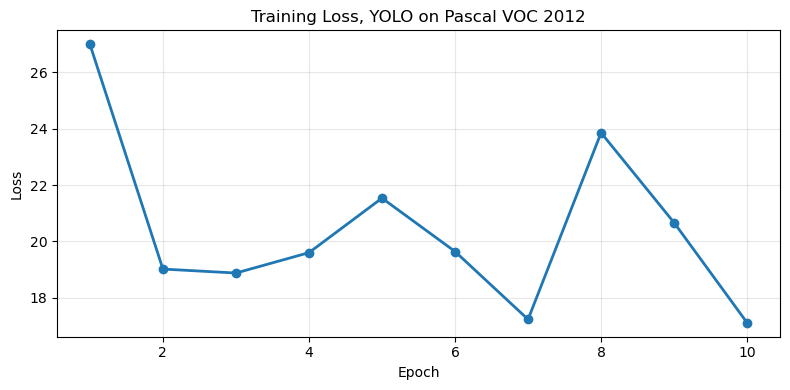

Starting loss : 26.9997
Final loss    : 17.1088
Reduction     : 36.6%


In [16]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss, YOLO on Pascal VOC 2012')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting loss : {history[0]:.4f}")
print(f"Final loss    : {history[-1]:.4f}")
print(f"Reduction     : {(1 - history[-1] / history[0]) * 100:.1f}%")

### 6.2 Detection Visualisation

We run the trained model on a random sample of validation images. The `decode_predictions` function converts the raw output tensor into `[class, confidence, cx, cy, w, h]` tuples, filtering out low-confidence guesses.

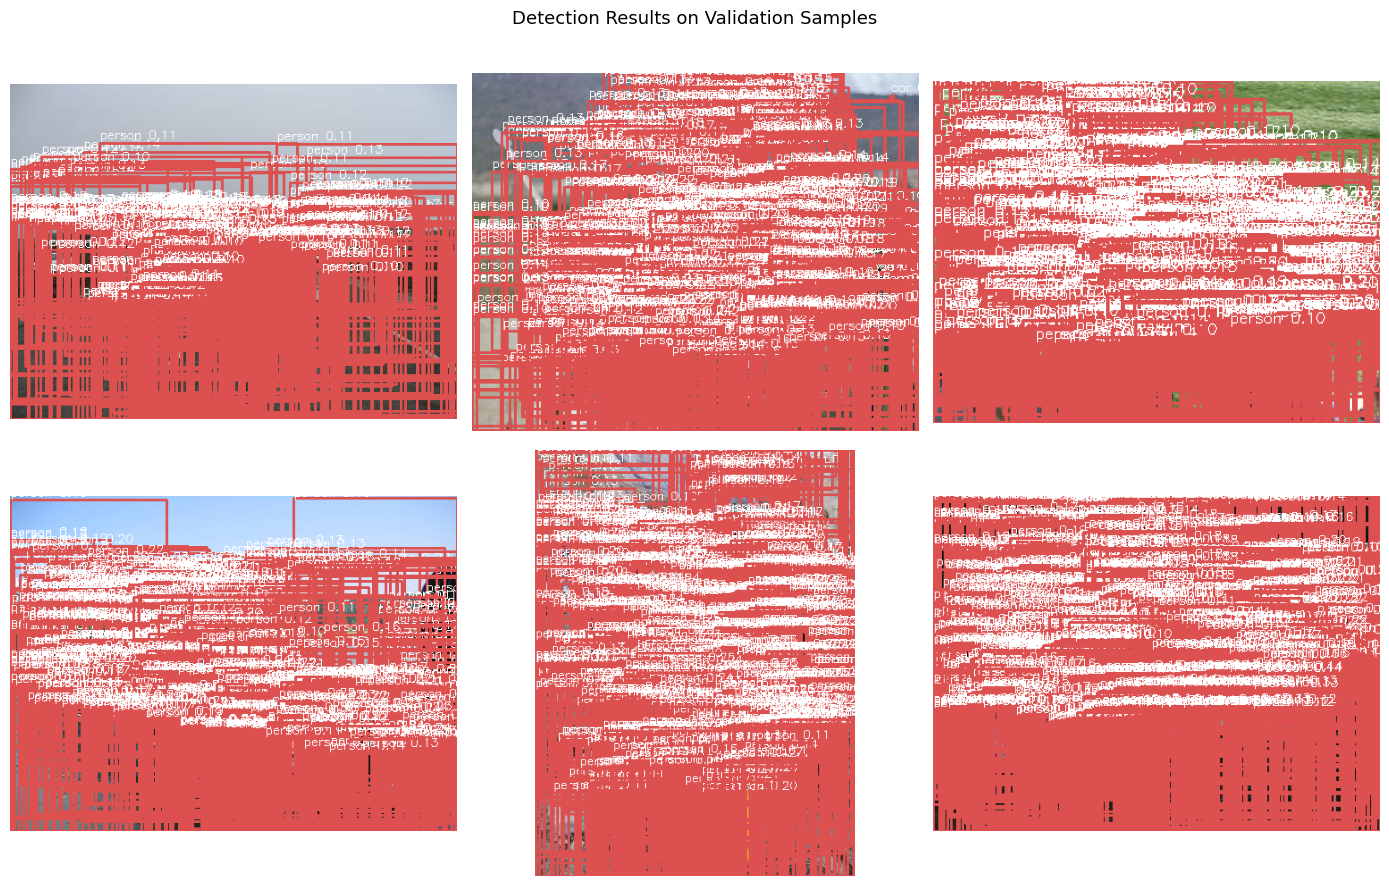

In [17]:
def decode_predictions(pred, S, B=3, C=20, conf_threshold=0.1):
    boxes = []
    pred = pred.detach().cpu()
    for i in range(S):
        for j in range(S):
            for b in range(B):
                offset = b * (5 + C)
                cx   = (torch.sigmoid(pred[i, j, offset]).item()   + j) / S
                cy   = (torch.sigmoid(pred[i, j, offset+1]).item() + i) / S
                w    = abs(pred[i, j, offset+2].item())
                h    = abs(pred[i, j, offset+3].item())
                conf = torch.sigmoid(pred[i, j, offset+4]).item()
                cls  = int(pred[i, j, offset+5:offset+5+C].argmax())
                if conf >= conf_threshold:
                    boxes.append([cls, conf, cx, cy, w, h])
    return boxes


model.eval()
transform_eval = T.Compose([T.ToPILImage(), T.Resize((HPARAMS['imgsz'], HPARAMS['imgsz'])), T.ToTensor()])
S_eval = HPARAMS['imgsz'] // 16

val_imgs = os.listdir('Pascal VOC 2012.v1/valid/images')
samples  = random.sample(val_imgs, 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, fname in zip(axes.flat, samples):
    path    = os.path.join('Pascal VOC 2012.v1/valid/images', fname)
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor  = transform_eval(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(tensor)[0]

    img_draw = img_rgb.copy()
    ih, iw   = img_draw.shape[:2]

    for cls, conf, cx, cy, w, h in decode_predictions(pred, S_eval):
        x1 = int((cx - w / 2) * iw)
        y1 = int((cy - h / 2) * ih)
        x2 = int((cx + w / 2) * iw)
        y2 = int((cy + h / 2) * ih)
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, iw), min(y2, ih)
        if x2 > x1 and y2 > y1:
            cv2.rectangle(img_draw, (x1, y1), (x2, y2), (220, 80, 80), 2)
            cv2.putText(img_draw, f"{VOC_CLASSES[cls]} {conf:.2f}",
                        (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

    ax.imshow(img_draw)
    ax.axis('off')

plt.suptitle('Detection Results on Validation Samples', fontsize=13)
plt.tight_layout()
plt.show()